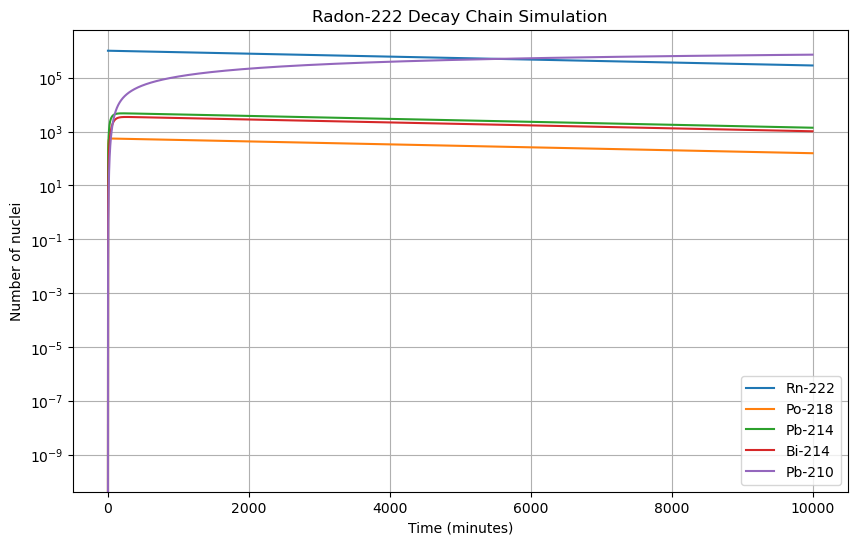

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Chain:
# Rn-222 -> Po-218 -> Pb-214 -> Bi-214 -> Pb-210
# Po-214 is skipped because its half-life is extremely tiny

N0 = 1000000

# time unit: minutes
day = 24 * 60

# half-lives in minutes
T_Rn222 = 3.82 * day
T_Po218 = 3.05
T_Pb214 = 26.8
T_Bi214 = 19.7

# decay constants
lam_Rn222 = np.log(2) / T_Rn222
lam_Po218 = np.log(2) / T_Po218
lam_Pb214 = np.log(2) / T_Pb214
lam_Bi214 = np.log(2) / T_Bi214

# time setup
dt = 0.01      # minutes
tmax = 10000     # minutes
times = np.arange(0, tmax, dt)

# arrays
Rn222 = np.zeros(len(times))
Po218 = np.zeros(len(times))
Pb214 = np.zeros(len(times))
Bi214 = np.zeros(len(times))
Pb210 = np.zeros(len(times))

# initial conditions
Rn222[0] = N0

# Euler loop
for i in range(len(times) - 1):

    N_Rn = Rn222[i]
    N_Po = Po218[i]
    N_Pb = Pb214[i]
    N_Bi = Bi214[i]
    N_Pb210 = Pb210[i]

    dRn = -lam_Rn222 * N_Rn * dt
    dPo = (lam_Rn222 * N_Rn - lam_Po218 * N_Po) * dt
    dPb = (lam_Po218 * N_Po - lam_Pb214 * N_Pb) * dt
    dBi = (lam_Pb214 * N_Pb - lam_Bi214 * N_Bi) * dt
    dPb210 = lam_Bi214 * N_Bi * dt

    Rn222[i+1] = N_Rn + dRn
    Po218[i+1] = N_Po + dPo
    Pb214[i+1] = N_Pb + dPb
    Bi214[i+1] = N_Bi + dBi
    Pb210[i+1] = N_Pb210 + dPb210

plt.figure(figsize=(10, 6))
plt.plot(times, Rn222, label="Rn-222")
plt.plot(times, Po218, label="Po-218")
plt.plot(times, Pb214, label="Pb-214")
plt.plot(times, Bi214, label="Bi-214")
plt.plot(times, Pb210, label="Pb-210")

plt.xlabel("Time (minutes)")
plt.ylabel("Number of nuclei")
plt.title("Radon-222 Decay Chain Simulation")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.show()